In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
bike = pd.read_csv('/content/sample_data/bike_sharing_daily.csv')

In [6]:
bike = bike.drop(columns=['instant', 'casual', 'registered'])

In [7]:
bike['dteday'] = pd.to_datetime(bike['dteday'], format='%m/%d/%Y')
bike.set_index('dteday', inplace=True)

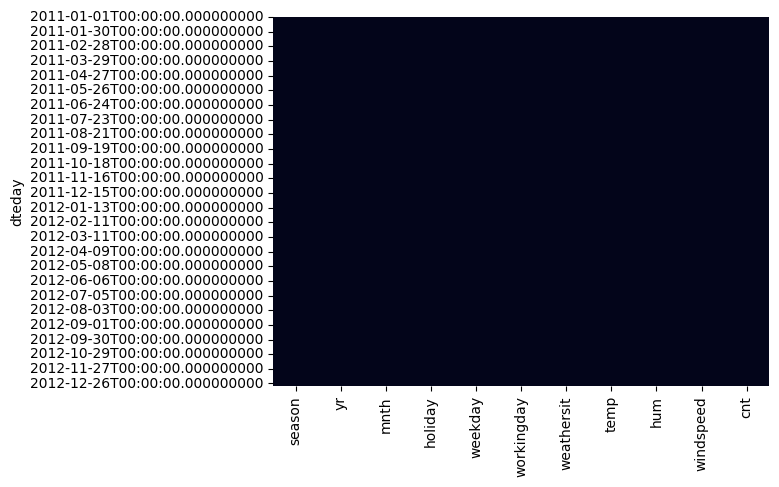

In [8]:
sns.heatmap(bike.isnull(), cbar=False)
plt.show()

In [9]:
bike.dropna(inplace=True)

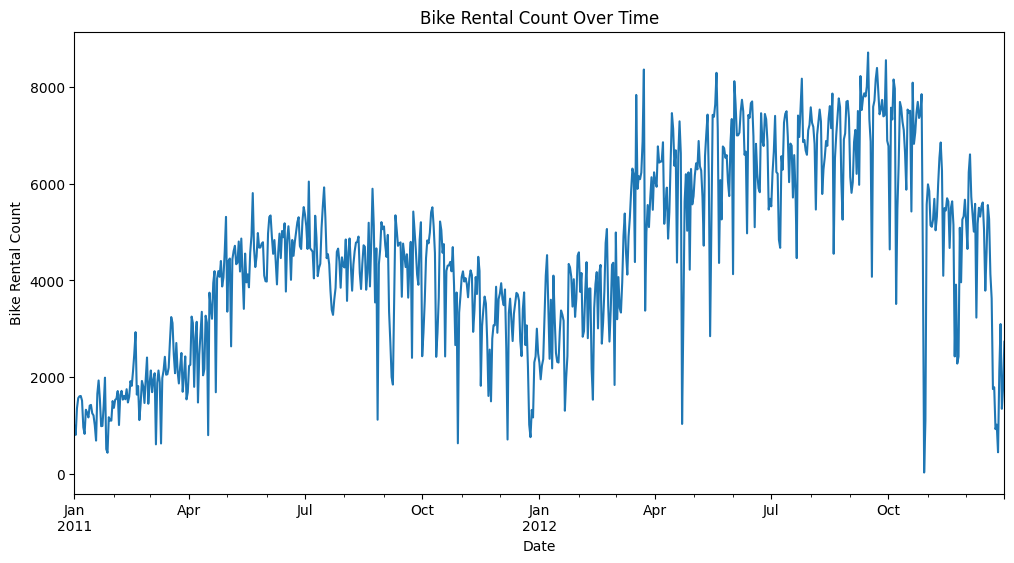

In [10]:
bike['cnt'].plot(figsize=(12, 6))
plt.title('Bike Rental Count Over Time')
plt.xlabel('Date')
plt.ylabel('Bike Rental Count')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features and target
X = bike.drop(columns=['cnt'])
y = bike['cnt']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build the model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 25080144.0000 - val_loss: 22508154.0000
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25463012.0000 - val_loss: 22497732.0000
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 25349428.0000 - val_loss: 22483604.0000
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 24805516.0000 - val_loss: 22464038.0000
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 24816322.0000 - val_loss: 22437046.0000
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25881356.0000 - val_loss: 22400538.0000
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25364426.0000 - val_loss: 22351560.0000
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 24690420.0000 - val_loss: 22288174.0000
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 24908092.0000 - val_loss: 22205144.0000
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24727818.0000 - val_loss: 22101464.0000
Epoch 11/50
1

In [13]:
from sklearn.metrics import mean_squared_error

# Predict on test data
y_pred = model.predict(X_test)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Mean Squared Error: 2733713.75


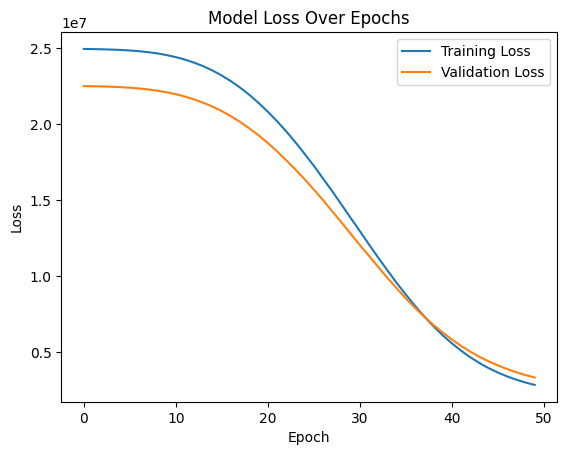

In [14]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()